In [43]:
import numpy as np
import torch
import torchvision.models
import torch.nn as nn
import pandas as pd
import time
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent.parent.parent))
from models.utils import set_seed, train, evaluate_model, plot_training_history, get_loaders
from models.baseline_cnn import BaselineCNN
from models.alexnet import ModifiedAlexNet

sys.path.append(str(Path().resolve().parent))
from hyperparameter_plots import summarize_results, print_summary_table, plot_loss_comparison, plot_accuracy_comparison
sys.path.append(str(Path().resolve().parent.parent))
from utils import save_results

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: mps


In [14]:
DATA_DIR = Path("../../../data")

TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

In [15]:
LEARNING_RATES = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]
SEEDS = [0, 1, 2]
BATCH_SIZE = 256

In [36]:
def create_baseline_model():
    model = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256], 
                        kernel_sizes = [3, 3, 3], fc_layers = [128, 64], num_classes = 10)
    return model

def create_resnet_model():
    model = torchvision.models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 10)
    model = model.to(device)
    return model

def create_alexnet_model():
    model = ModifiedAlexNet(num_classes=10).to(device)
    return model

def test_learning_rate(model, train_loader, valid_loader, test_loader, learning_rates,
        seeds, scheduler=None, device=None, num_epochs=20):
    
    results = {}
    for lr in learning_rates:
        results[lr] = {}
        for seed in seeds:
            print(f"\nLEARNING RATE={lr} | SEED={seed}")
            set_seed(seed)

            model_instance = model()
            criterion = torch.nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(model_instance.parameters(), lr=lr)

            print("------------------------------------------------------")


            history = train(model_instance, train_loader, valid_loader, criterion, optimizer,
                scheduler=scheduler, device=device, num_epochs=num_epochs, verbose=True, verbose_interval=int(num_epochs/10))
            
            
            validation_accuracy = history['valid_acc'][-1]
            validation_loss = history['valid_loss'][-1]
            test_accuracy, test_loss = evaluate_model(model_instance, test_loader, criterion, device)

            results[lr][seed] = {
                "history": history,
                "valid_acc": validation_accuracy,
                "valid_loss": validation_loss,
                "test_acc": test_accuracy,
                "test_loss": test_loss
            }

            print("------------------------------------------------------")

            print(f"VALIDATION ACCURACY: {validation_accuracy:.4f} | TEST ACCURACY: {test_accuracy:.4f}")

            print("------------------------------------------------------")

    return results

def test_no_epochs(model, train_loader, valid_loader, test_loader, no_epochs,
        seeds, scheduler=None, device=None):
    
    results = {}
    for epochs in no_epochs:
        results[epochs] = {}
        for seed in seeds:
            print(f"\nNUMBER OF EPOCHS={epochs} | SEED={seed}")
            set_seed(seed)

            model_instance = model()
            criterion = torch.nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(model_instance.parameters(), lr=1e-3)

            print("------------------------------------------------------")


            history = train(model_instance, train_loader, valid_loader, criterion, optimizer,
                scheduler=scheduler, device=device, num_epochs=epochs, verbose=True, verbose_interval=max(1, int(epochs / 10)))
            
            
            validation_accuracy = history['valid_acc'][-1]
            validation_loss = history['valid_loss'][-1]
            test_accuracy, test_loss = evaluate_model(model_instance, test_loader, criterion, device)

            results[epochs][seed] = {
                "history": history,
                "valid_acc": validation_accuracy,
                "valid_loss": validation_loss,
                "test_acc": test_accuracy,
                "test_loss": test_loss
            }

            print("------------------------------------------------------")

            print(f"VALIDATION ACCURACY: {validation_accuracy:.4f} | TEST ACCURACY: {test_accuracy:.4f}")

            print("------------------------------------------------------")

    return results

In [17]:
train_loader, valid_loader, test_loader = get_loaders(train_dir=TRAIN_DIR, valid_dir=VALID_DIR,
                                                      test_dir=TEST_DIR, image_size=32, batch_size=BATCH_SIZE)

## Learning rates experiments

#### Baseline model

In [111]:
baseline_results = test_learning_rate(model=create_baseline_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, learning_rates=LEARNING_RATES, seeds=SEEDS, num_epochs=20, device=device)


LEARNING RATE=0.01 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 1.3166 | Valid Loss: 1.3109 | Valid Acc: 0.5260
Epoch 4/20 | Train Loss: 1.0511 | Valid Loss: 1.1712 | Valid Acc: 0.5763
Epoch 6/20 | Train Loss: 0.8686 | Valid Loss: 1.0024 | Valid Acc: 0.6477
Epoch 8/20 | Train Loss: 0.7296 | Valid Loss: 1.0960 | Valid Acc: 0.6244
Epoch 10/20 | Train Loss: 0.5964 | Valid Loss: 0.9929 | Valid Acc: 0.6689
Epoch 12/20 | Train Loss: 0.4961 | Valid Loss: 1.0151 | Valid Acc: 0.6718
Epoch 14/20 | Train Loss: 0.3904 | Valid Loss: 1.1447 | Valid Acc: 0.6612
Epoch 16/20 | Train Loss: 0.3210 | Valid Loss: 1.2102 | Valid Acc: 0.6761
Epoch 18/20 | Train Loss: 0.2573 | Valid Loss: 1.4335 | Valid Acc: 0.6480
Epoch 20/20 | Train Loss: 0.2229 | Valid Loss: 1.4670 | Valid Acc: 0.6641
Best validation accuracy: 0.6761
------------------------------------------------------
VALIDATION ACCURACY: 0.6641 | TEST ACCURACY: 0.6616
----------------------------------------

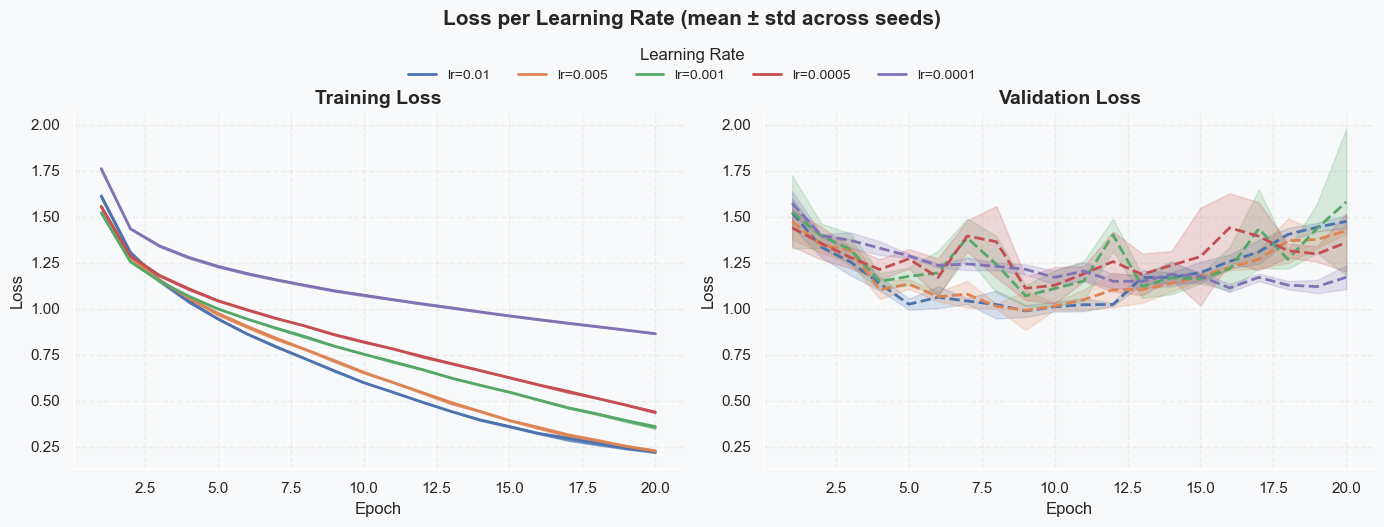

In [201]:
plot_loss_comparison(baseline_results, param_name="Learning Rate", param_name_short = 'lr')

In [156]:
for param, seed_dict in baseline_results.items():
    train_losses = np.array([seed_dict[s]['history']['train_loss'] for s in seed_dict])
    print(f"lr={param} | seeds={train_losses.shape[0]} | max std={train_losses.std(axis=0).max():.6f}")

lr=0.01 | seeds=3 | max std=0.011411
lr=0.005 | seeds=3 | max std=0.009002
lr=0.001 | seeds=3 | max std=0.009218
lr=0.0005 | seeds=3 | max std=0.007536
lr=0.0001 | seeds=3 | max std=0.006289


In [198]:
df = summarize_results(baseline_results)
df

,Model,lr,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,0.0100,0.662652,0.007941,1.473861,0.034226,0.660130,0.005960,1.489238,0.028669
1,Model,0.0050,0.664219,0.004882,1.423667,0.015430,0.663311,0.004820,1.432439,0.016287
2,Model,0.0010,0.607081,0.050102,1.579780,0.398951,0.605885,0.050891,1.595699,0.402124
3,Model,0.0005,0.607615,0.033626,1.359750,0.158624,0.605759,0.033533,1.380732,0.167520
4,Model,0.0001,0.587196,0.022987,1.170571,0.064861,0.584470,0.022296,1.181267,0.063467


In [199]:
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,0.0100,0.6627 ± 0.0079,1.4739 ± 0.0342,0.6601 ± 0.0060,1.4892 ± 0.0287
1,Model,0.0050,0.6642 ± 0.0049,1.4237 ± 0.0154,0.6633 ± 0.0048,1.4324 ± 0.0163
2,Model,0.0010,0.6071 ± 0.0501,1.5798 ± 0.3990,0.6059 ± 0.0509,1.5957 ± 0.4021
3,Model,0.0005,0.6076 ± 0.0336,1.3598 ± 0.1586,0.6058 ± 0.0335,1.3807 ± 0.1675
4,Model,0.0001,0.5872 ± 0.0230,1.1706 ± 0.0649,0.5845 ± 0.0223,1.1813 ± 0.0635


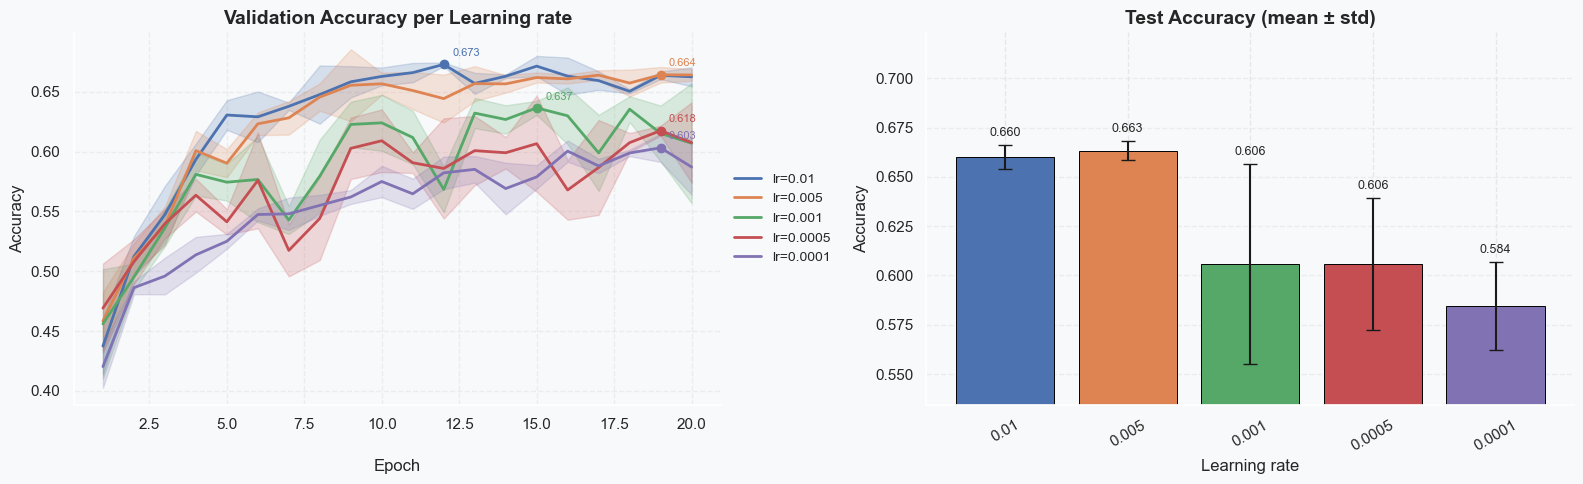

In [200]:
plot_accuracy_comparison(baseline_results, param_name='Learning rate', param_name_short='lr')

In [ ]:
save_results(baseline_results, 'lr_results_baseline')

#### Alexnet

In [18]:
alexnet_results = test_learning_rate(model=create_alexnet_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, learning_rates=LEARNING_RATES, seeds=SEEDS, num_epochs=20, device=device)


LEARNING RATE=0.01 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 2.2022 | Valid Loss: 2.1219 | Valid Acc: 0.1570
Epoch 4/20 | Train Loss: 2.1427 | Valid Loss: 1.9329 | Valid Acc: 0.2602
Epoch 6/20 | Train Loss: 1.6750 | Valid Loss: 1.6495 | Valid Acc: 0.3516
Epoch 8/20 | Train Loss: 1.5165 | Valid Loss: 1.5212 | Valid Acc: 0.3868
Epoch 10/20 | Train Loss: 1.3938 | Valid Loss: 1.3258 | Valid Acc: 0.5029
Epoch 12/20 | Train Loss: 1.3657 | Valid Loss: 1.3057 | Valid Acc: 0.5126
Epoch 14/20 | Train Loss: 1.1917 | Valid Loss: 1.1417 | Valid Acc: 0.5927
Epoch 16/20 | Train Loss: 1.1094 | Valid Loss: 1.0893 | Valid Acc: 0.6232
Epoch 18/20 | Train Loss: 1.0250 | Valid Loss: 1.1628 | Valid Acc: 0.6004
Epoch 20/20 | Train Loss: 0.9608 | Valid Loss: 1.0359 | Valid Acc: 0.6434
Best validation accuracy: 0.6434
------------------------------------------------------
VALIDATION ACCURACY: 0.6434 | TEST ACCURACY: 0.6438
----------------------------------------

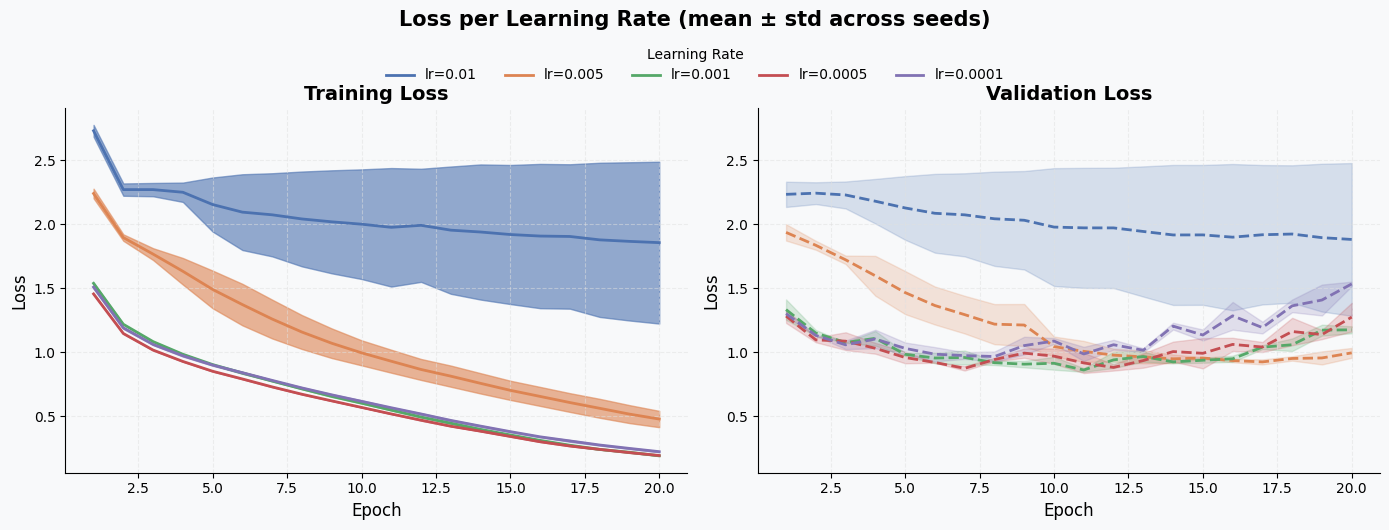

In [19]:
plot_loss_comparison(alexnet_results, param_name="Learning Rate", param_name_short = 'lr')

In [20]:
for param, seed_dict in alexnet_results.items():
    train_losses = np.array([seed_dict[s]['history']['train_loss'] for s in seed_dict])
    print(f"lr={param} | seeds={train_losses.shape[0]} | max std={train_losses.std(axis=0).max():.6f}")

lr=0.01 | seeds=3 | max std=0.632761
lr=0.005 | seeds=3 | max std=0.162302
lr=0.001 | seeds=3 | max std=0.006092
lr=0.0005 | seeds=3 | max std=0.004017
lr=0.0001 | seeds=3 | max std=0.009854


In [21]:
df = summarize_results(alexnet_results)
df

,Model,lr,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,0.0100,0.281122,0.256146,1.880632,0.597318,0.281267,0.256350,1.882870,0.594152
1,Model,0.0050,0.689570,0.010170,0.993879,0.038587,0.687281,0.010573,1.007773,0.036892
2,Model,0.0010,0.717526,0.011017,1.174095,0.027310,0.716563,0.011439,1.185701,0.027313
3,Model,0.0005,0.703648,0.008997,1.273563,0.111765,0.700900,0.008285,1.297089,0.108777
4,Model,0.0001,0.660837,0.001447,1.532947,0.017726,0.658896,0.001029,1.557242,0.021479


In [22]:
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,0.0100,0.2811 ± 0.2561,1.8806 ± 0.5973,0.2813 ± 0.2563,1.8829 ± 0.5942
1,Model,0.0050,0.6896 ± 0.0102,0.9939 ± 0.0386,0.6873 ± 0.0106,1.0078 ± 0.0369
2,Model,0.0010,0.7175 ± 0.0110,1.1741 ± 0.0273,0.7166 ± 0.0114,1.1857 ± 0.0273
3,Model,0.0005,0.7036 ± 0.0090,1.2736 ± 0.1118,0.7009 ± 0.0083,1.2971 ± 0.1088
4,Model,0.0001,0.6608 ± 0.0014,1.5329 ± 0.0177,0.6589 ± 0.0010,1.5572 ± 0.0215


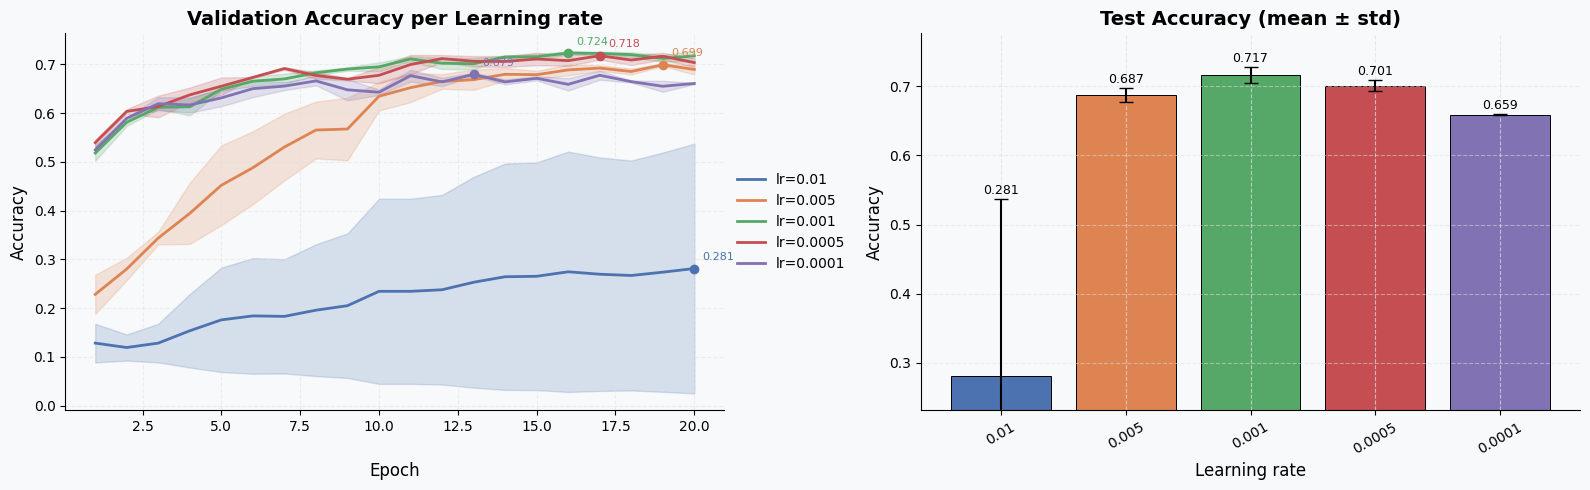

In [30]:
plot_accuracy_comparison(alexnet_results, param_name='Learning rate', param_name_short='lr')

In [23]:
save_results(alexnet_results, 'lr_results_alexnet.json')

#### Resnet model

In [24]:
resnet_results = test_learning_rate(model=create_resnet_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, learning_rates=LEARNING_RATES, seeds=SEEDS, num_epochs=20, device=device)


LEARNING RATE=0.01 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 1.3997 | Valid Loss: 1.3161 | Valid Acc: 0.5268
Epoch 4/20 | Train Loss: 1.1075 | Valid Loss: 1.1737 | Valid Acc: 0.5741
Epoch 6/20 | Train Loss: 0.9143 | Valid Loss: 1.1053 | Valid Acc: 0.6079
Epoch 8/20 | Train Loss: 0.7320 | Valid Loss: 1.1242 | Valid Acc: 0.6199
Epoch 10/20 | Train Loss: 0.5410 | Valid Loss: 1.2552 | Valid Acc: 0.6226
Epoch 12/20 | Train Loss: 0.3719 | Valid Loss: 1.4372 | Valid Acc: 0.6152
Epoch 14/20 | Train Loss: 0.2572 | Valid Loss: 1.6228 | Valid Acc: 0.6054
Epoch 16/20 | Train Loss: 0.1820 | Valid Loss: 1.8608 | Valid Acc: 0.6065
Epoch 18/20 | Train Loss: 0.1430 | Valid Loss: 2.0200 | Valid Acc: 0.6113
Epoch 20/20 | Train Loss: 0.1205 | Valid Loss: 2.0683 | Valid Acc: 0.6086
Best validation accuracy: 0.6226
------------------------------------------------------
VALIDATION ACCURACY: 0.6086 | TEST ACCURACY: 0.6075
----------------------------------------

In [25]:
save_results(resnet_results, 'lr_results_resnet.json')

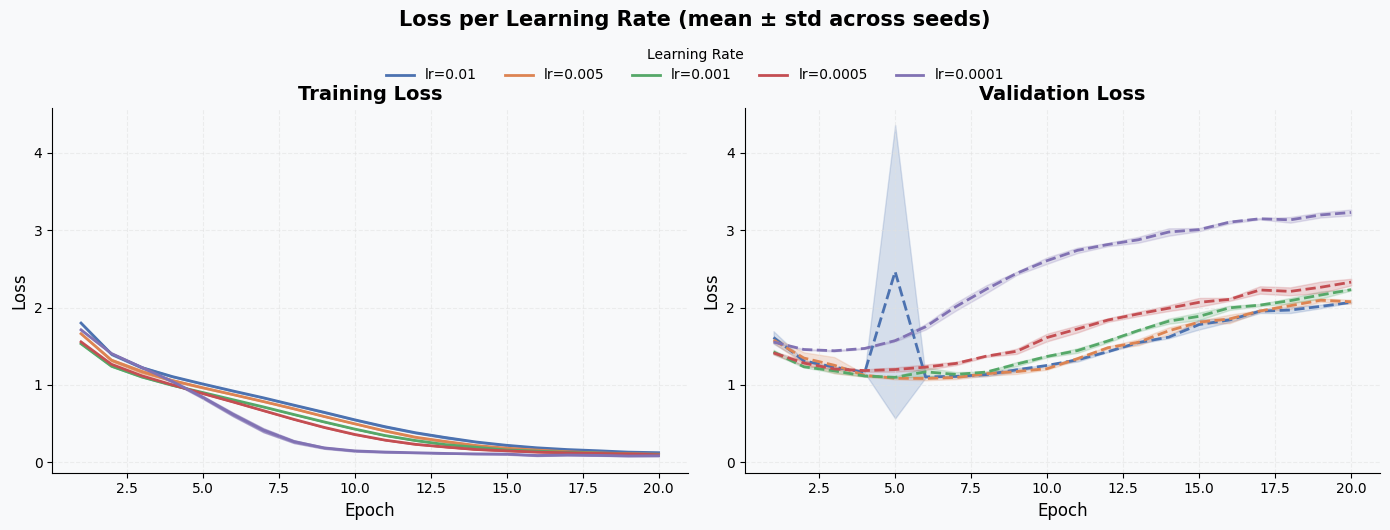

In [26]:
plot_loss_comparison(resnet_results, param_name="Learning Rate", param_name_short = 'lr')

In [27]:
df = summarize_results(resnet_results)
df

,Model,lr,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,0.0100,0.608689,0.000264,2.067167,0.000914,0.609189,0.001303,2.071418,0.004207
1,Model,0.0050,0.617830,0.001652,2.075008,0.026568,0.618407,0.001998,2.076910,0.018978
2,Model,0.0010,0.610470,0.000152,2.231420,0.011308,0.609874,0.000777,2.242389,0.012255
3,Model,0.0005,0.587393,0.004071,2.328738,0.043416,0.586804,0.004095,2.335712,0.050420
4,Model,0.0001,0.474200,0.001854,3.229261,0.038605,0.474507,0.001975,3.240331,0.035739


In [28]:
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,0.0100,0.6087 ± 0.0003,2.0672 ± 0.0009,0.6092 ± 0.0013,2.0714 ± 0.0042
1,Model,0.0050,0.6178 ± 0.0017,2.0750 ± 0.0266,0.6184 ± 0.0020,2.0769 ± 0.0190
2,Model,0.0010,0.6105 ± 0.0002,2.2314 ± 0.0113,0.6099 ± 0.0008,2.2424 ± 0.0123
3,Model,0.0005,0.5874 ± 0.0041,2.3287 ± 0.0434,0.5868 ± 0.0041,2.3357 ± 0.0504
4,Model,0.0001,0.4742 ± 0.0019,3.2293 ± 0.0386,0.4745 ± 0.0020,3.2403 ± 0.0357


In [29]:
for param, seed_dict in resnet_results.items():
    train_losses = np.array([seed_dict[s]['history']['train_loss'] for s in seed_dict])
    print(f"lr={param} | seeds={train_losses.shape[0]} | max std={train_losses.std(axis=0).max():.6f}")

lr=0.01 | seeds=3 | max std=0.012569
lr=0.005 | seeds=3 | max std=0.018643
lr=0.001 | seeds=3 | max std=0.004441
lr=0.0005 | seeds=3 | max std=0.003964
lr=0.0001 | seeds=3 | max std=0.025279


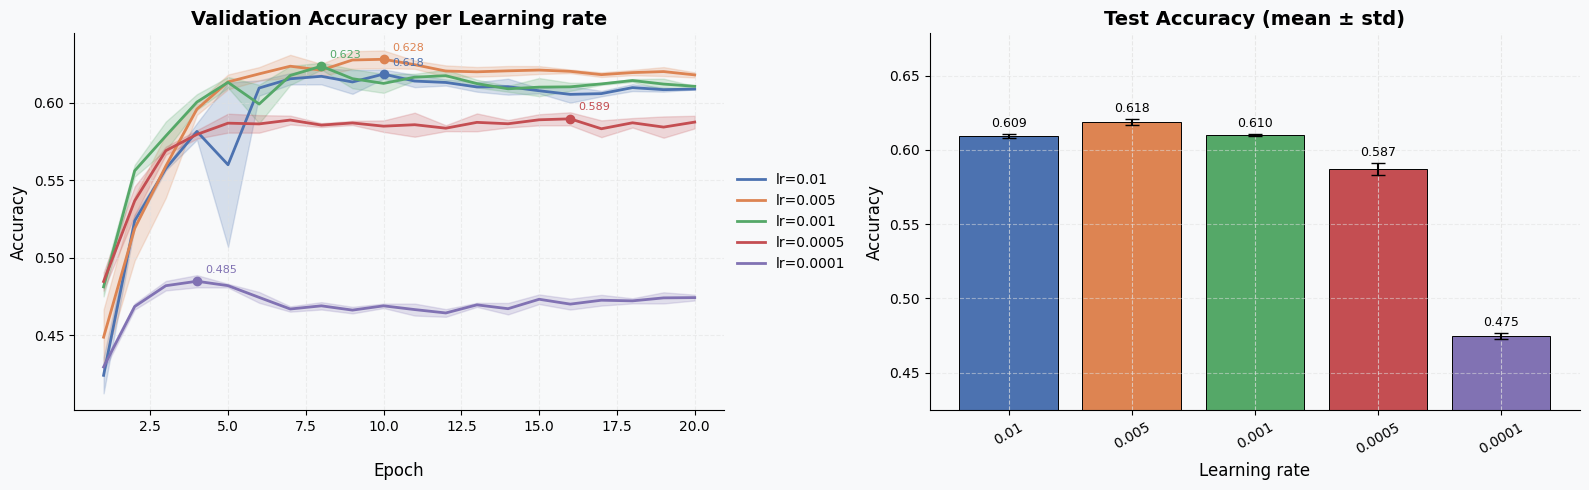

In [31]:
plot_accuracy_comparison(resnet_results, param_name='Learning rate', param_name_short='lr')

## Number of epochs experiments

In [32]:
NUMBER_OF_EPOCHS = [5, 10, 20, 30, 40]
SEEDS = [0,1,2]

In [37]:
baseline_results_epochs = test_no_epochs(model=create_baseline_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, no_epochs=NUMBER_OF_EPOCHS, seeds=SEEDS, device=device)


NUMBER OF EPOCHS=5 | SEED=0
------------------------------------------------------
Epoch 1/5 | Train Loss: 1.5315 | Valid Loss: 1.4085 | Valid Acc: 0.4781
Epoch 2/5 | Train Loss: 1.2618 | Valid Loss: 1.4892 | Valid Acc: 0.4800
Epoch 3/5 | Train Loss: 1.1482 | Valid Loss: 1.4457 | Valid Acc: 0.5151
Epoch 4/5 | Train Loss: 1.0681 | Valid Loss: 1.1893 | Valid Acc: 0.5669
Epoch 5/5 | Train Loss: 0.9973 | Valid Loss: 1.1389 | Valid Acc: 0.5860
Best validation accuracy: 0.5860
------------------------------------------------------
VALIDATION ACCURACY: 0.5860 | TEST ACCURACY: 0.5867
------------------------------------------------------

NUMBER OF EPOCHS=5 | SEED=1
------------------------------------------------------
Epoch 1/5 | Train Loss: 1.5157 | Valid Loss: 1.8045 | Valid Acc: 0.3922
Epoch 2/5 | Train Loss: 1.2530 | Valid Loss: 1.3504 | Valid Acc: 0.4992
Epoch 3/5 | Train Loss: 1.1483 | Valid Loss: 1.2534 | Valid Acc: 0.5503
Epoch 4/5 | Train Loss: 1.0690 | Valid Loss: 1.1710 | Valid A

In [38]:
save_results(baseline_results_epochs, 'epochs_results_baseline.json')

In [40]:
alexnet_results_epochs = test_no_epochs(model=create_alexnet_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, no_epochs=NUMBER_OF_EPOCHS, seeds=SEEDS, device=device)


NUMBER OF EPOCHS=5 | SEED=0
------------------------------------------------------
Epoch 1/5 | Train Loss: 1.5340 | Valid Loss: 1.4445 | Valid Acc: 0.4956
Epoch 2/5 | Train Loss: 1.2191 | Valid Loss: 1.1159 | Valid Acc: 0.5903
Epoch 3/5 | Train Loss: 1.0809 | Valid Loss: 1.0757 | Valid Acc: 0.6082
Epoch 4/5 | Train Loss: 0.9799 | Valid Loss: 1.0318 | Valid Acc: 0.6376
Epoch 5/5 | Train Loss: 0.9025 | Valid Loss: 0.9658 | Valid Acc: 0.6526
Best validation accuracy: 0.6526
------------------------------------------------------
VALIDATION ACCURACY: 0.6526 | TEST ACCURACY: 0.6504
------------------------------------------------------

NUMBER OF EPOCHS=5 | SEED=1
------------------------------------------------------
Epoch 1/5 | Train Loss: 1.5451 | Valid Loss: 1.2747 | Valid Acc: 0.5312
Epoch 2/5 | Train Loss: 1.2153 | Valid Loss: 1.1704 | Valid Acc: 0.5721
Epoch 3/5 | Train Loss: 1.0815 | Valid Loss: 1.0768 | Valid Acc: 0.6102
Epoch 4/5 | Train Loss: 0.9875 | Valid Loss: 1.1215 | Valid A

In [41]:
save_results(alexnet_results_epochs, 'epochs_results_alexnet.json')

In [44]:
resnet_results_epochs = test_no_epochs(model=create_resnet_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, no_epochs=NUMBER_OF_EPOCHS, seeds=SEEDS, device=device)


NUMBER OF EPOCHS=5 | SEED=0
------------------------------------------------------
Epoch 1/5 | Train Loss: 1.5309 | Valid Loss: 1.4659 | Valid Acc: 0.4725
Epoch 2/5 | Train Loss: 1.2365 | Valid Loss: 1.2239 | Valid Acc: 0.5614
Epoch 3/5 | Train Loss: 1.1010 | Valid Loss: 1.1450 | Valid Acc: 0.5915
Epoch 4/5 | Train Loss: 0.9961 | Valid Loss: 1.1279 | Valid Acc: 0.5938
Epoch 5/5 | Train Loss: 0.9016 | Valid Loss: 1.0855 | Valid Acc: 0.6169
Best validation accuracy: 0.6169
------------------------------------------------------
VALIDATION ACCURACY: 0.6169 | TEST ACCURACY: 0.6169
------------------------------------------------------

NUMBER OF EPOCHS=5 | SEED=1
------------------------------------------------------
Epoch 1/5 | Train Loss: 1.5367 | Valid Loss: 1.4071 | Valid Acc: 0.4862
Epoch 2/5 | Train Loss: 1.2411 | Valid Loss: 1.2344 | Valid Acc: 0.5533
Epoch 3/5 | Train Loss: 1.0988 | Valid Loss: 1.1929 | Valid Acc: 0.5720
Epoch 4/5 | Train Loss: 0.9900 | Valid Loss: 1.1122 | Valid A

In [45]:
save_results(resnet_results_epochs, 'epochs_results_resnet.json')